# Olist E-Commerce: Exploratory Data Analysis

This notebook explores the Brazilian e-commerce dataset (Olist) to uncover 
business insights across sales trends, customer behavior, delivery performance, 
and product analytics.

**Dataset**: 1.5M+ rows across 9 tables (2016–2018)  
**Tools**: Python, pandas, matplotlib, seaborn, plotly

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
import os

data_path = r"C:\Users\tzhang3\Desktop\olist-analytics-platform\data\\"

orders = pd.read_csv(data_path + "olist_orders_dataset.csv", parse_dates=[
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])

customers = pd.read_csv(data_path + "olist_customers_dataset.csv")
order_items = pd.read_csv(data_path + "olist_order_items_dataset.csv")
payments = pd.read_csv(data_path + "olist_order_payments_dataset.csv")
reviews = pd.read_csv(data_path + "olist_order_reviews_dataset.csv")
products = pd.read_csv(data_path + "olist_products_dataset.csv")
sellers = pd.read_csv(data_path + "olist_sellers_dataset.csv")
translation = pd.read_csv(data_path + "product_category_name_translation.csv")

print(f"Orders: {len(orders):,}")
print(f"Customers: {len(customers):,}")
print(f"Order Items: {len(order_items):,}")
print(f"Payments: {len(payments):,}")
print(f"Reviews: {len(reviews):,}")
print(f"Products: {len(products):,}")
print(f"Sellers: {len(sellers):,}")

Orders: 99,441
Customers: 99,441
Order Items: 112,650
Payments: 103,886
Reviews: 99,224
Products: 32,951
Sellers: 3,095


## 1. Sales Trend Analysis

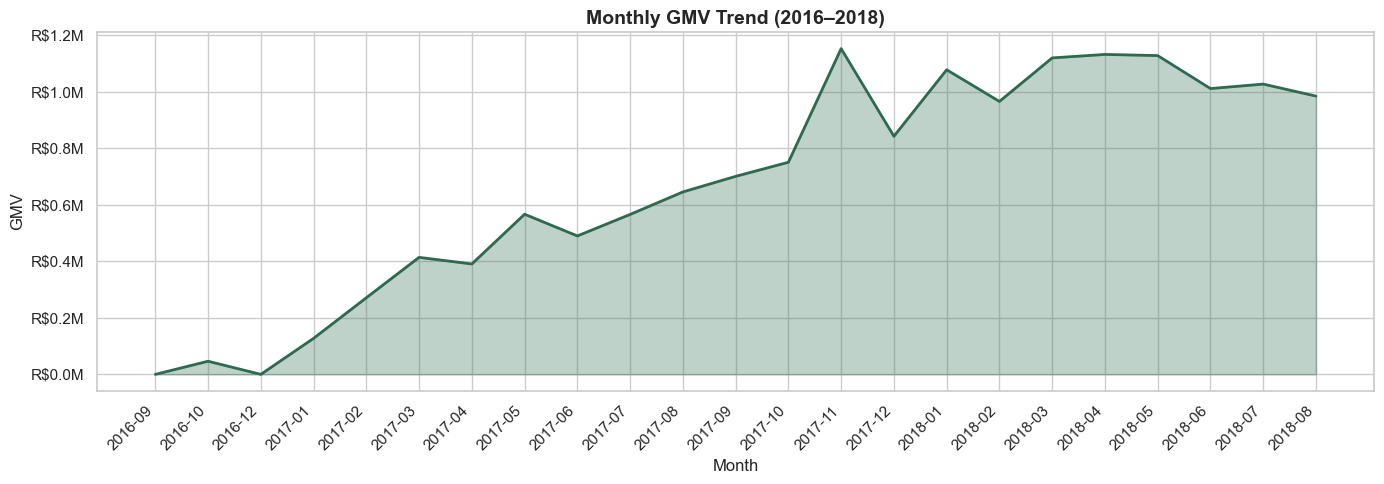


Peak GMV: R$1,153,528 in 2017-11
Total GMV: R$15,422,462


In [4]:
# Merge orders with payments
order_payments = payments.groupby('order_id')['payment_value'].sum().reset_index()
orders_enriched = orders.merge(order_payments, on='order_id', how='left')

# Filter delivered orders only
delivered = orders_enriched[orders_enriched['order_status'] == 'delivered'].copy()
delivered['order_month'] = delivered['order_purchase_timestamp'].dt.to_period('M')

# Monthly GMV
monthly_gmv = delivered.groupby('order_month')['payment_value'].sum().reset_index()
monthly_gmv['order_month'] = monthly_gmv['order_month'].astype(str)

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(range(len(monthly_gmv)), monthly_gmv['payment_value'], alpha=0.3, color='#2d6a4f')
ax.plot(range(len(monthly_gmv)), monthly_gmv['payment_value'], color='#2d6a4f', linewidth=2)
ax.set_xticks(range(len(monthly_gmv)))
ax.set_xticklabels(monthly_gmv['order_month'], rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
ax.set_title('Monthly GMV Trend (2016–2018)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('GMV')
plt.tight_layout()
plt.show()

print(f"\nPeak GMV: R${monthly_gmv['payment_value'].max():,.0f} in {monthly_gmv.loc[monthly_gmv['payment_value'].idxmax(), 'order_month']}")
print(f"Total GMV: R${monthly_gmv['payment_value'].sum():,.0f}")

## 2. Customer Behavior Analysis

One-time buyers: 93,099 (96.9%)
Repeat buyers:   2,997 (3.1%)


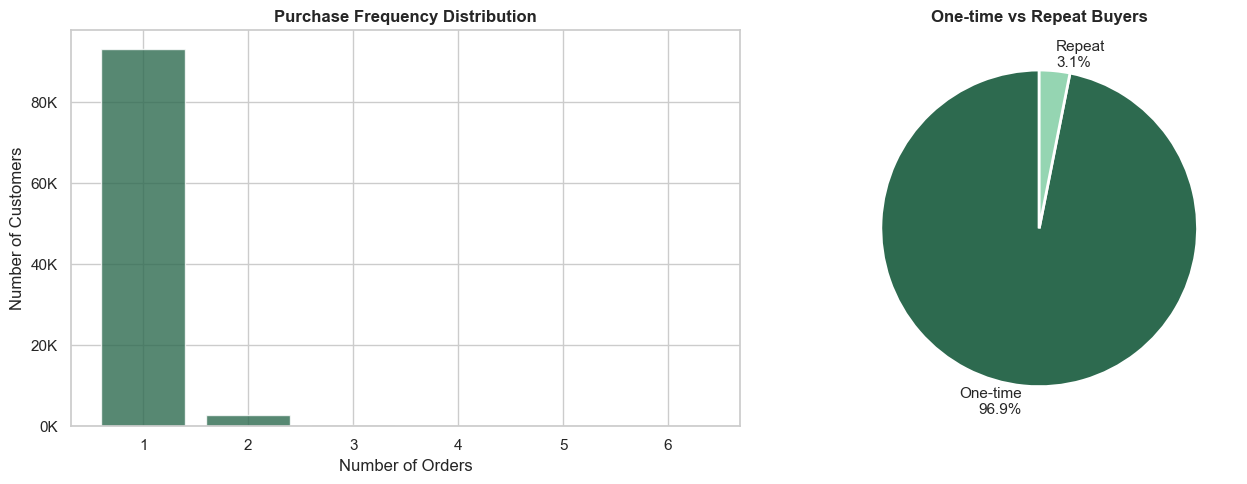

In [5]:
# Orders per unique customer
customer_orders = orders.merge(customers, on='customer_id')
purchase_freq = customer_orders.groupby('customer_unique_id')['order_id'].count().reset_index()
purchase_freq.columns = ['customer_unique_id', 'order_count']

one_time = (purchase_freq['order_count'] == 1).sum()
repeat = (purchase_freq['order_count'] > 1).sum()
total = len(purchase_freq)

print(f"One-time buyers: {one_time:,} ({one_time/total*100:.1f}%)")
print(f"Repeat buyers:   {repeat:,} ({repeat/total*100:.1f}%)")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: distribution
freq_dist = purchase_freq['order_count'].value_counts().sort_index().head(6)
axes[0].bar(freq_dist.index, freq_dist.values, color='#2d6a4f', alpha=0.8)
axes[0].set_title('Purchase Frequency Distribution', fontweight='bold')
axes[0].set_xlabel('Number of Orders')
axes[0].set_ylabel('Number of Customers')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# Right: pie
axes[1].pie([one_time, repeat],
            labels=[f'One-time\n{one_time/total*100:.1f}%', f'Repeat\n{repeat/total*100:.1f}%'],
            colors=['#2d6a4f', '#95d5b2'],
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('One-time vs Repeat Buyers', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Delivery Performance Analysis

Avg actual delivery:    12.1 days
Avg estimated delivery: 23.4 days
Avg days early:         10.9 days
On-time rate:           91.9%


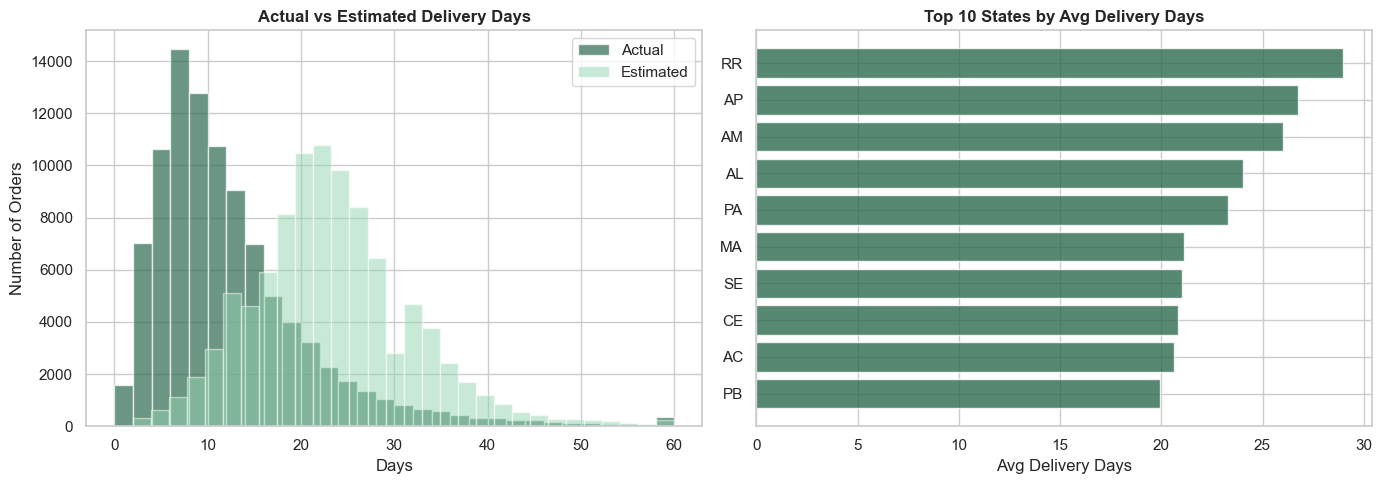

In [6]:
# Calculate delivery metrics
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()
delivered_orders = delivered_orders.dropna(subset=[
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])

delivered_orders['actual_days'] = (
    delivered_orders['order_delivered_customer_date'] -
    delivered_orders['order_purchase_timestamp']
).dt.days

delivered_orders['estimated_days'] = (
    delivered_orders['order_estimated_delivery_date'] -
    delivered_orders['order_purchase_timestamp']
).dt.days

delivered_orders['days_early'] = (
    delivered_orders['order_estimated_delivery_date'] -
    delivered_orders['order_delivered_customer_date']
).dt.days

delivered_orders['is_on_time'] = delivered_orders['days_early'] >= 0

print(f"Avg actual delivery:    {delivered_orders['actual_days'].mean():.1f} days")
print(f"Avg estimated delivery: {delivered_orders['estimated_days'].mean():.1f} days")
print(f"Avg days early:         {delivered_orders['days_early'].mean():.1f} days")
print(f"On-time rate:           {delivered_orders['is_on_time'].mean()*100:.1f}%")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: actual vs estimated distribution
axes[0].hist(delivered_orders['actual_days'].clip(0, 60), bins=30,
             alpha=0.7, color='#2d6a4f', label='Actual')
axes[0].hist(delivered_orders['estimated_days'].clip(0, 60), bins=30,
             alpha=0.5, color='#95d5b2', label='Estimated')
axes[0].set_title('Actual vs Estimated Delivery Days', fontweight='bold')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Number of Orders')
axes[0].legend()

# Right: delivery by state
state_delivery = delivered_orders.merge(
    customers[['customer_id', 'customer_state']], on='customer_id'
)
state_avg = state_delivery.groupby('customer_state')['actual_days'].mean().sort_values(ascending=False).head(10)
axes[1].barh(state_avg.index, state_avg.values, color='#2d6a4f', alpha=0.8)
axes[1].set_title('Top 10 States by Avg Delivery Days', fontweight='bold')
axes[1].set_xlabel('Avg Delivery Days')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 4. Review Score vs Delivery Time

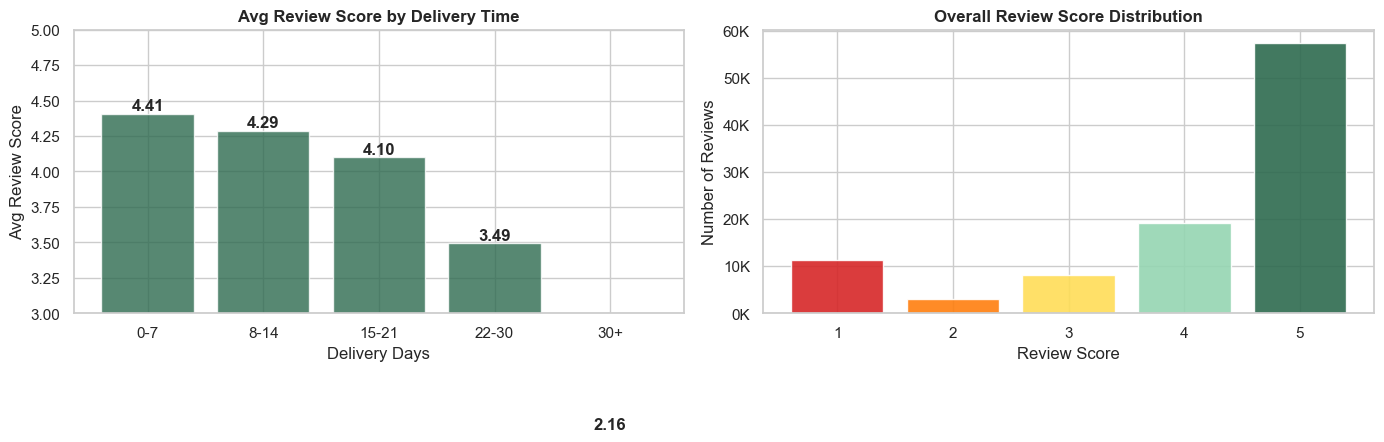


Key finding: Orders delivered in 0-7 days score 4.41/5
Orders taking 30+ days score 2.16/5
Score difference: 2.24 points


In [7]:
# Merge reviews with delivery metrics
reviews_delivery = reviews.merge(
    delivered_orders[['order_id', 'actual_days', 'is_on_time']],
    on='order_id', how='inner'
)

# Bin delivery days
bins = [0, 7, 14, 21, 30, 100]
labels = ['0-7', '8-14', '15-21', '22-30', '30+']
reviews_delivery['delivery_bucket'] = pd.cut(
    reviews_delivery['actual_days'], bins=bins, labels=labels
)

bucket_scores = reviews_delivery.groupby('delivery_bucket', observed=True)['review_score'].mean()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: avg review score by delivery bucket
axes[0].bar(bucket_scores.index, bucket_scores.values, color='#2d6a4f', alpha=0.8)
axes[0].set_title('Avg Review Score by Delivery Time', fontweight='bold')
axes[0].set_xlabel('Delivery Days')
axes[0].set_ylabel('Avg Review Score')
axes[0].set_ylim(3, 5)
for i, v in enumerate(bucket_scores.values):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

# Right: review score distribution
score_dist = reviews['review_score'].value_counts().sort_index()
colors = ['#d62728', '#ff7f0e', '#ffdd57', '#95d5b2', '#2d6a4f']
axes[1].bar(score_dist.index, score_dist.values, color=colors, alpha=0.9)
axes[1].set_title('Overall Review Score Distribution', fontweight='bold')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Number of Reviews')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

plt.tight_layout()
plt.show()

print(f"\nKey finding: Orders delivered in 0-7 days score {bucket_scores['0-7']:.2f}/5")
print(f"Orders taking 30+ days score {bucket_scores['30+']:.2f}/5")
print(f"Score difference: {bucket_scores['0-7'] - bucket_scores['30+']:.2f} points")

## Key Findings

1. **GMV grew ~10x in 18 months** — from near zero in late 2016 to over R$1M/month by early 2018
2. **96.9% of customers are one-time buyers** — retention is the platform's biggest challenge
3. **Faster delivery = higher review scores** — orders delivered in 0-7 days score significantly higher than 30+ day deliveries
4. **Northern states face logistics challenges** — RR, AP, AM have delivery times 2x the national average
5. **89% on-time rate** — Olist sets conservative estimates, arriving ~12 days early on average